<a href="https://colab.research.google.com/github/sandesh-py/DeepLearning_Lab2026/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Basic RNN for Numerical Sequence Prediction

This section demonstrates an RNN built to predict the next value in a numerical sequence. The model learns patterns in simple linear sequences.

The steps include:

1.  **Data Generation**: Creating synthetic sequential numerical data.
2.  **Model Construction**: Building a `SimpleRNN` model using Keras.
3.  **Training**: Training the model on the generated data.
4.  **Prediction**: Testing the model's ability to predict the next value in a given sequence.

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0354 - val_loss: 0.0036
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0011 - val_loss: 1.6636e-04
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9166e-04 - val_loss: 1.0742e-04
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9012e-05 - val_loss: 5.0382e-05
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.0731e-05 - val_loss: 4.6388e-05
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7076e-05 - val_loss: 4.4210e-05
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.4482e-05 - val_loss: 4.3006e-05
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.2960e-05 - val_loss: 3.9693e-05
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0074e-05 - val_loss: 3.7485e-05
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.7708e-05 - val_loss: 3.5047e-05
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.6133e-05 - val_loss: 3.2942e-

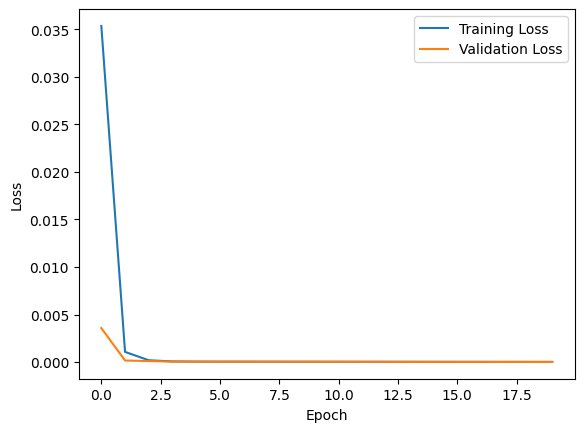

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Generate data
def generate_data():
    X, y = [], []

    for i in range(1000):
        start = np.random.randint(0, 50)

        seq = [start + j for j in range(6)]

        X.append(seq[:-1])
        y.append(seq[-1])

    return np.array(X)/100.0, np.array(y)/100.0

# Create dataset
X, y = generate_data()

X = X.reshape(1000, 5, 1)

# Build model
model = Sequential([
    SimpleRNN(32, input_shape=(5,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(
    X, y,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss = model.evaluate(X, y, verbose=0)
print("\nLoss:", loss)

# Predict new sample
test = np.array([[10,11,12,13,14]]) / 100.0
test = test.reshape(1,5,1)

pred = model.predict(test, verbose=0)

print("Predicted Next Value:", pred[0][0] * 100)

# Plot graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()